In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.DataFrame({"method": ["baseline", "augmented", "constraints"]})

In [3]:
data_dict = {}
modes = ["train", "val"]
metrics = ["loss", "f1"]
methods = ["baseline", "augmented", "const"]
seeds = [0, 1, 2]
baseline = []
for method in methods:
    for metric in metrics:
        for mode in modes:
            scores = []
            for seed in seeds:
                data = pd.read_csv(f"epoch_data/{mode}_{metric}_{method}_{seed}.csv")
                scores.append(data["value"])
            data_dict[f"{method}_{mode}_{metric}"] = sum(scores)/len(seeds)
print(data_dict)

{'baseline_train_loss': 0    1.753359
1    1.357930
2    0.852587
3    0.589020
4    0.430487
5    0.323860
6    0.258265
7    0.219462
Name: value, dtype: float64, 'baseline_val_loss': 0    1.692709
1    1.364086
2    1.376390
3    1.733199
4    1.711131
5    2.072443
6    2.406417
7    2.887281
Name: value, dtype: float64, 'baseline_train_f1': 0    0.185976
1    0.413514
2    0.576583
3    0.665228
4    0.729725
5    0.784180
6    0.816572
7    0.837913
Name: value, dtype: float64, 'baseline_val_f1': 0    0.226166
1    0.408170
2    0.450326
3    0.452346
4    0.473179
5    0.460086
6    0.453871
7    0.430646
Name: value, dtype: float64, 'augmented_train_loss': 0    1.758287
1    1.374253
2    0.845541
3    0.566826
4    0.401824
5    0.303628
6    0.251706
7    0.216895
8    0.183193
9         NaN
Name: value, dtype: float64, 'augmented_val_loss': 0    1.691933
1    1.344844
2    1.424860
3    1.588711
4    1.802829
5    2.048500
6    2.380230
7    2.502638
8    2.937888
9         

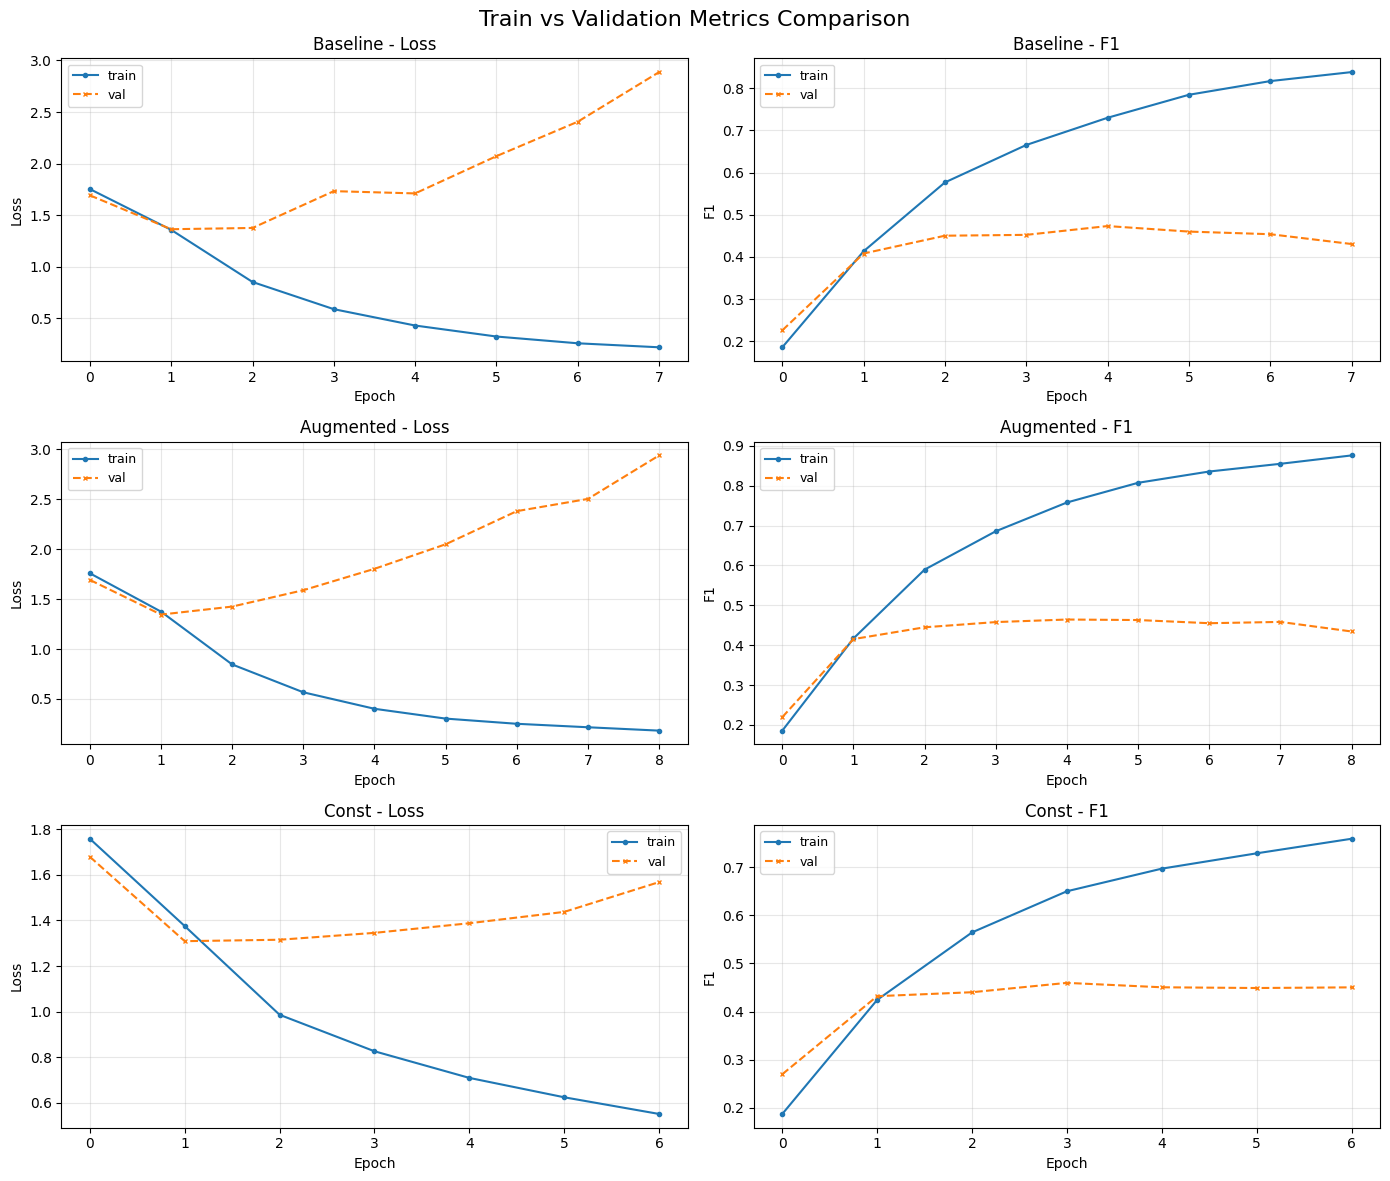

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Train vs Validation Metrics Comparison', fontsize=16)

metrics = ['loss', 'f1']
methods = ["baseline", "augmented", "const"]

for method_idx, method in enumerate(methods):
    for metric_idx, metric in enumerate(metrics):
        ax = axes[method_idx, metric_idx]
        
        train_key = f'{method}_train_{metric}'
        val_key = f'{method}_val_{metric}'
        
        if train_key in data_dict and val_key in data_dict:
            train_data = data_dict[train_key]
            val_data = data_dict[val_key]
            epochs = range(len(train_data))
            
            # Plot train
            ax.plot(epochs, train_data, 
                   label='train', linestyle='-', marker='o', markersize=3)
            
            # Plot val
            ax.plot(epochs, val_data, 
                   label='val', linestyle='--', marker='x', markersize=3)
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f'{method.capitalize()} - {metric.capitalize()}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

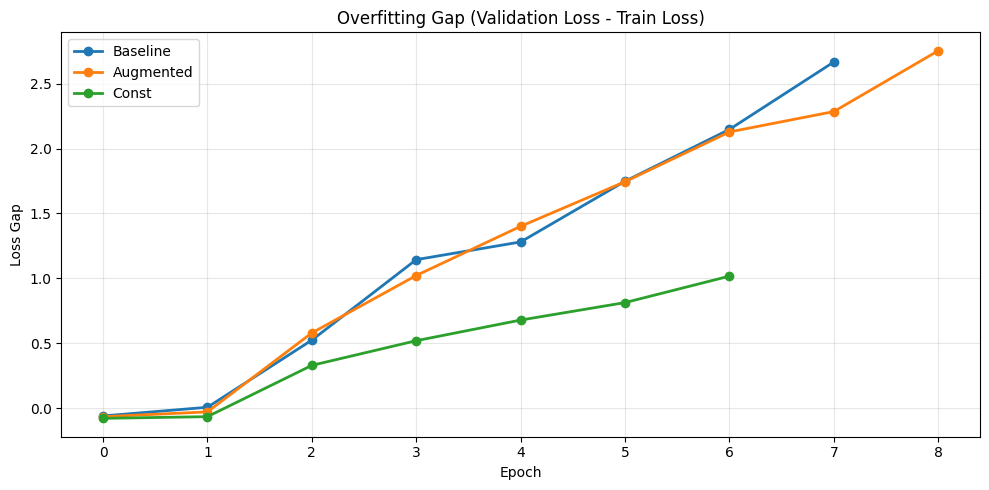

In [5]:
methods = ["baseline", "augmented", "const"]

# Compute gap for each method
gap_dict = {}

for method in methods:
    train_key = f'{method}_train_loss'
    val_key = f'{method}_val_loss'
    
    if train_key in data_dict and val_key in data_dict:
        train_loss = data_dict[train_key]
        val_loss = data_dict[val_key]
        
        # Ensure same length
        epochs = min(len(train_loss), len(val_loss))
        train_loss = train_loss[:epochs]
        val_loss = val_loss[:epochs]
        
        # Gap = val_loss - train_loss (higher = more overfitting)
        gap = [v - t for v, t in zip(val_loss, train_loss)]
        gap_dict[method] = gap

# Plot Figure 2
plt.figure(figsize=(10, 5))
for method, gap in gap_dict.items():
    plt.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

plt.title("Overfitting Gap (Validation Loss - Train Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss Gap")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=300, bbox_inches="tight")
plt.show()


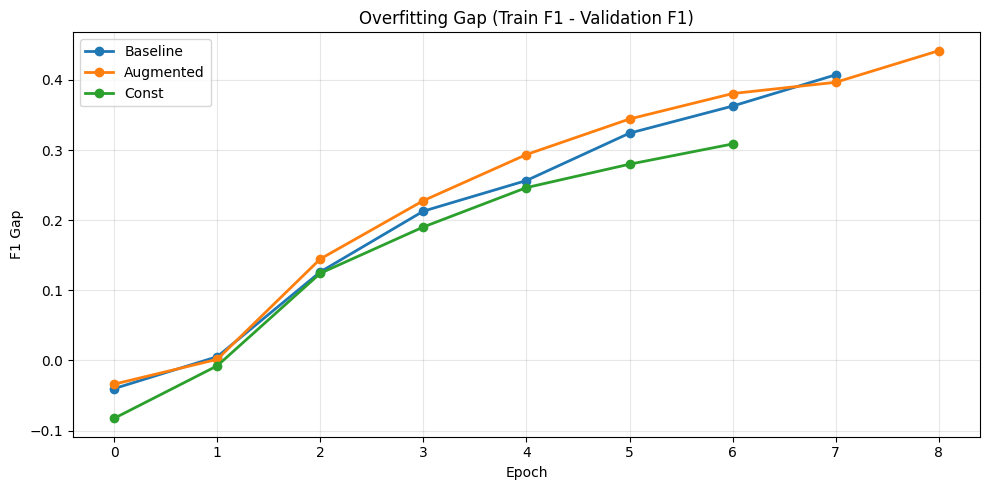

In [6]:
methods = ["baseline", "augmented", "const"]

# Compute F1 gap for each method
f1_gap_dict = {}

for method in methods:
    train_key = f'{method}_train_f1'
    val_key = f'{method}_val_f1'
    
    if train_key in data_dict and val_key in data_dict:
        train_f1 = data_dict[train_key]
        val_f1 = data_dict[val_key]
        
        # Ensure same length
        epochs = min(len(train_f1), len(val_f1))
        train_f1 = train_f1[:epochs]
        val_f1 = val_f1[:epochs]
        
        # Gap = train_f1 - val_f1 (higher = more overfitting)
        gap = [t - v for t, v in zip(train_f1, val_f1)]
        f1_gap_dict[method] = gap

# Plot F1 Gap
plt.figure(figsize=(10, 5))
for method, gap in f1_gap_dict.items():
    plt.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

plt.title("Overfitting Gap (Train F1 - Validation F1)")
plt.xlabel("Epoch")
plt.ylabel("F1 Gap")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("f1_overfitting_gap.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
methods = ["baseline", "augmented", "const"]

table_data = []

for method in methods:
    # Get F1 data
    train_f1_key = f'{method}_train_f1'
    val_f1_key = f'{method}_val_f1'
    train_loss_key = f'{method}_train_loss'
    val_loss_key = f'{method}_val_loss'
    
    if val_f1_key in data_dict:
        val_f1 = data_dict[val_f1_key]
        train_f1 = data_dict[train_f1_key]
        val_loss = data_dict[val_loss_key]
        train_loss = data_dict[train_loss_key]
        
        # Find epoch with best validation F1
        best_val_f1 = val_f1.max()
        best_epoch = val_f1.idxmax()
        
        # Get corresponding train F1 and losses at that epoch
        train_f1_at_best = train_f1.iloc[best_epoch]
        f1_gap = best_val_f1 - train_f1_at_best
        
        val_loss_at_best = val_loss.iloc[best_epoch]
        train_loss_at_best = train_loss.iloc[best_epoch]
        loss_gap = val_loss_at_best - train_loss_at_best
        
        table_data.append({
            'Method': method.capitalize(),
            'Best Val F1': f'{best_val_f1:.4f}',
            'Epoch (best val)': int(best_epoch),
            'Train F1 @ best val': f'{train_f1_at_best:.4f}',
            'F1 Gap': f'{f1_gap:.4f}',
            'Val Loss @ best val': f'{val_loss_at_best:.4f}',
            'Train Loss @ best val': f'{train_loss_at_best:.4f}',
            'Loss Gap': f'{loss_gap:.4f}'
        })

results_df = pd.DataFrame(table_data)
results_df

,Method,Best Val F1,Epoch (best val),Train F1 @ best val,F1 Gap,Val Loss @ best val,Train Loss @ best val,Loss Gap
0,Baseline,0.4732,4,0.7297,-0.2565,1.7111,0.4305,1.2806
1,Augmented,0.4643,4,0.7580,-0.2936,1.8028,0.4018,1.4010
2,Const,0.4597,3,0.6500,-0.1903,1.3454,0.8261,0.5194


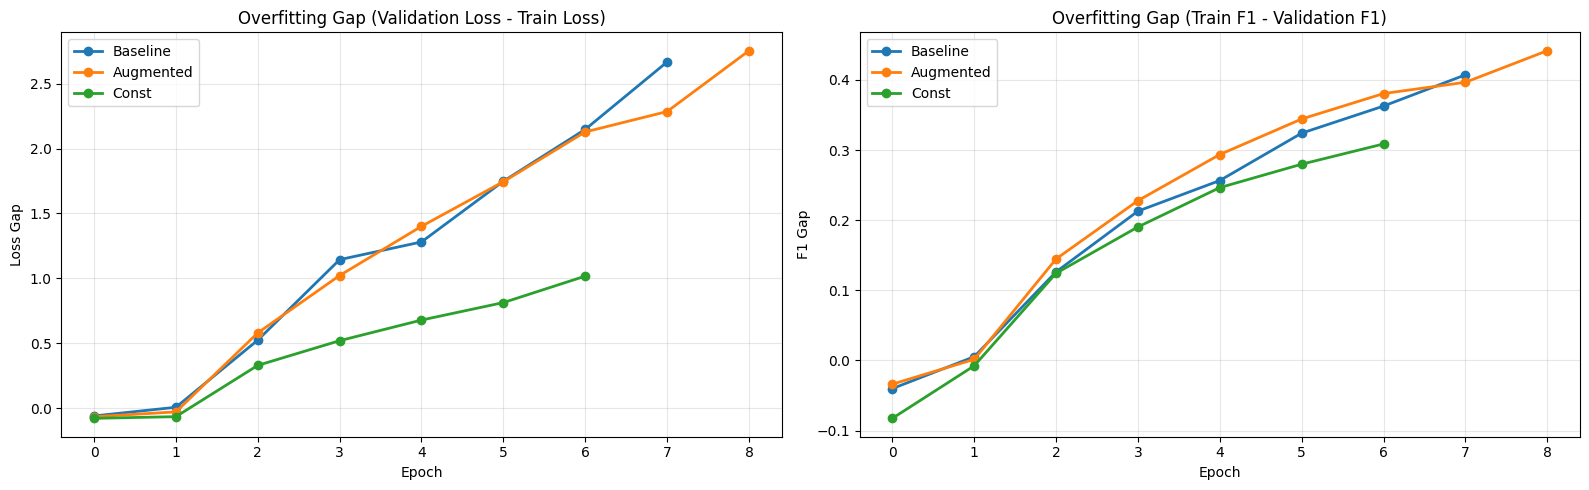

In [8]:
methods = ["baseline", "augmented", "const"]

# Compute loss gap for each method
gap_dict = {}
for method in methods:
    train_key = f'{method}_train_loss'
    val_key = f'{method}_val_loss'
    
    if train_key in data_dict and val_key in data_dict:
        train_loss = data_dict[train_key]
        val_loss = data_dict[val_key]
        
        epochs = min(len(train_loss), len(val_loss))
        train_loss = train_loss[:epochs]
        val_loss = val_loss[:epochs]
        
        gap = [v - t for v, t in zip(val_loss, train_loss)]
        gap_dict[method] = gap

# Compute F1 gap for each method
f1_gap_dict = {}
for method in methods:
    train_key = f'{method}_train_f1'
    val_key = f'{method}_val_f1'
    
    if train_key in data_dict and val_key in data_dict:
        train_f1 = data_dict[train_key]
        val_f1 = data_dict[val_key]
        
        epochs = min(len(train_f1), len(val_f1))
        train_f1 = train_f1[:epochs]
        val_f1 = val_f1[:epochs]
        
        gap = [t - v for t, v in zip(train_f1, val_f1)]
        f1_gap_dict[method] = gap

# Create combined figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Loss Gap
for method, gap in gap_dict.items():
    ax1.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

ax1.set_title("Overfitting Gap (Validation Loss - Train Loss)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss Gap")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot F1 Gap
for method, gap in f1_gap_dict.items():
    ax2.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

ax2.set_title("Overfitting Gap (Train F1 - Validation F1)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1 Gap")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig("combined_overfitting_gaps.png", dpi=300, bbox_inches="tight")
plt.show()

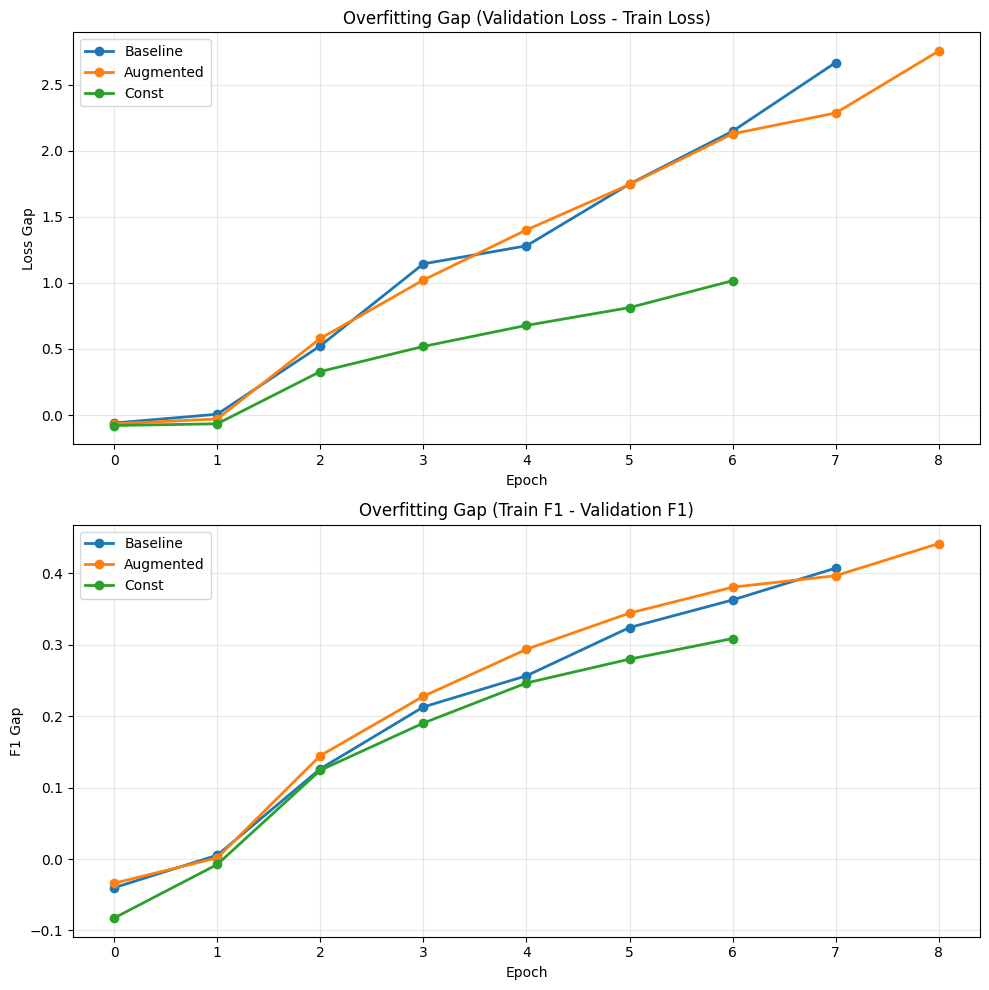

In [9]:
# Create combined figure with vertical stacking
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Plot Loss Gap
for method, gap in gap_dict.items():
    ax1.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

ax1.set_title("Overfitting Gap (Validation Loss - Train Loss)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss Gap")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot F1 Gap
for method, gap in f1_gap_dict.items():
    ax2.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

ax2.set_title("Overfitting Gap (Train F1 - Validation F1)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1 Gap")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()